In [18]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [21]:
print("Dataset Shape:", df.shape)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (1470, 35)

Rows: 1470
Columns: 35

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [22]:
print("First 10 Rows")

df.head(10)

First 10 Rows


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [23]:
print("Target Column:")
print(df["Attrition"])

Target Column:
0       Yes
1        No
2       Yes
3        No
4        No
       ... 
1465     No
1466     No
1467     No
1468     No
1469     No
Name: Attrition, Length: 1470, dtype: object


In [24]:
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

attrition_rate = (attrition_counts["Yes"] / len(df)) * 100

print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


In [25]:
numeric_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

print("\nCategorical Features:")
print(categorical_cols.tolist())

Numeric Columns: 26
Categorical Columns: 9

Categorical Features:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


##Task 1 Observations:
The dataset contains 1470 employee records with 35 features. The target variable is Attrition, which indicates whether an employee left the company. Approximately 16.12% of employees have left the organization, making this an imbalanced classification problem. Therefore, techniques such as class_weight='balanced' will be used during model training to improve prediction performance.

In [26]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

In [27]:
# Drop irrelevant columns
df.drop(
    columns=["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"],
    inplace=True
)

print("New Dataset Shape:", df.shape)

New Dataset Shape: (1470, 31)


In [28]:
# Convert target column to numeric
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df["Attrition"].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [29]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [30]:
# One-Hot Encode categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Dataset Shape after Encoding:", df.shape)


Dataset Shape after Encoding: (1470, 45)


In [31]:
# Features (X) and Target (y)
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (1470, 44)
Target Shape: (1470,)


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1176, 44)
Testing Set: (294, 44)


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed!")

Scaling Completed!


In [34]:
# Reload original dataset for EDA
eda_df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Convert Attrition to numeric for calculations
eda_df["Attrition"] = eda_df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

eda_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


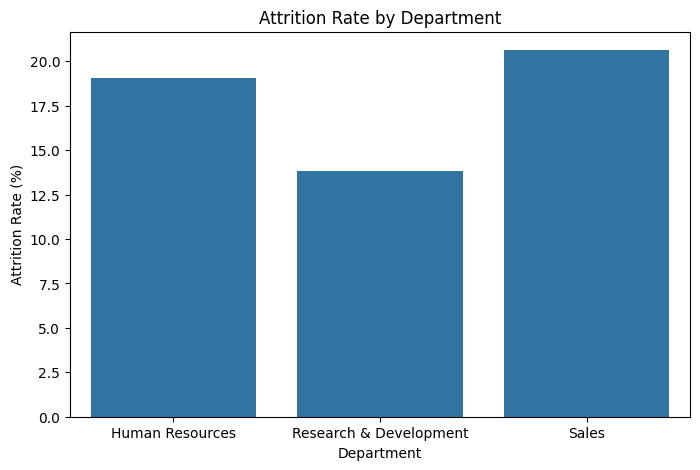

In [35]:
plt.figure(figsize=(8,5))

department_attrition = eda_df.groupby("Department")["Attrition"].mean() * 100

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.savefig("chart1_department_attrition.png", dpi=300, bbox_inches="tight")
plt.show()

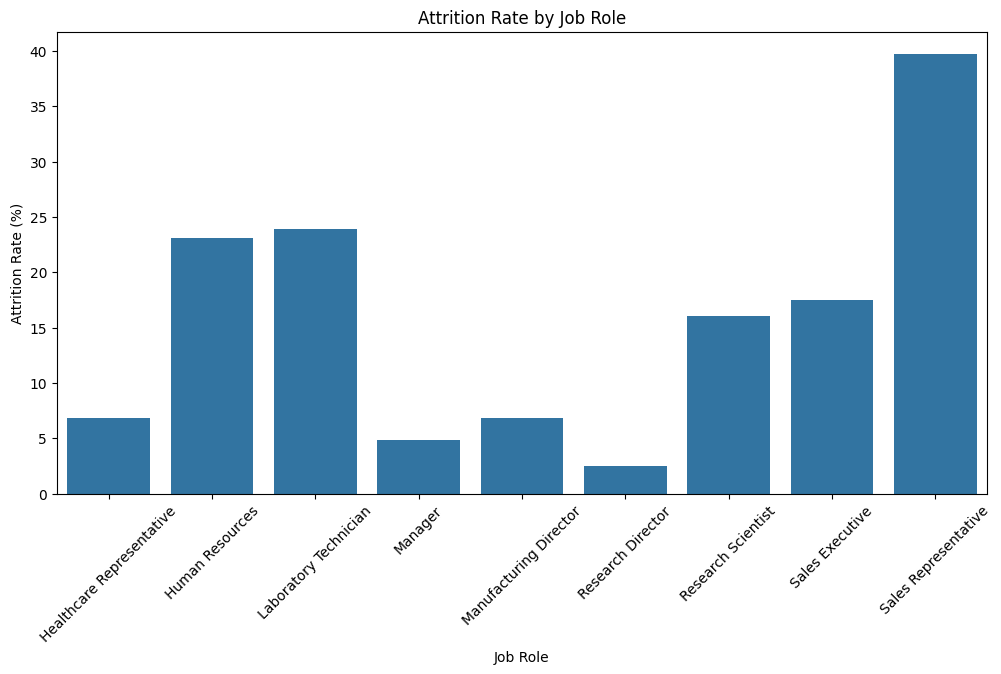

In [36]:
plt.figure(figsize=(12,6))

job_attrition = eda_df.groupby("JobRole")["Attrition"].mean() * 100

sns.barplot(
    x=job_attrition.index,
    y=job_attrition.values
)

plt.xticks(rotation=45)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.savefig("chart2_jobrole_attrition.png", dpi=300, bbox_inches="tight")

plt.show()

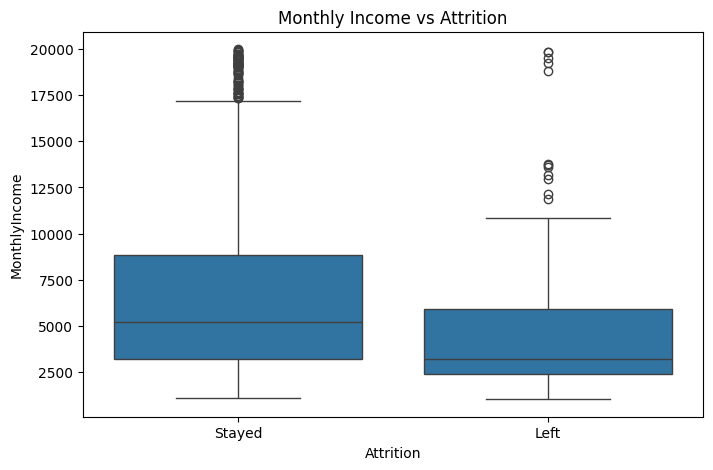

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=eda_df
)

plt.xticks([0,1], ["Stayed","Left"])

plt.title("Monthly Income vs Attrition")

plt.savefig("chart3_income_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

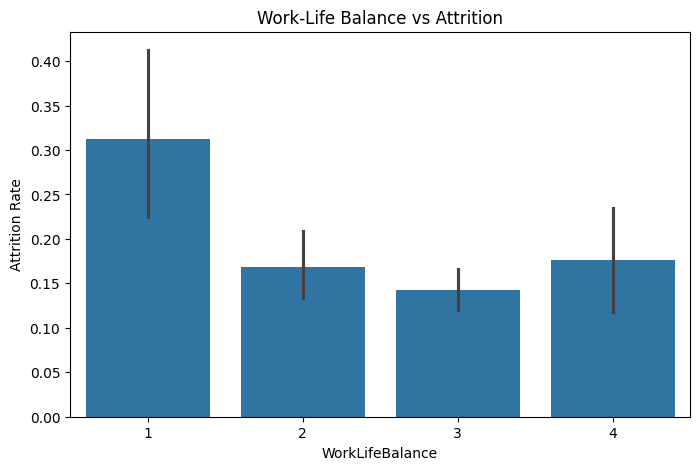

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="WorkLifeBalance",
    y="Attrition",
    data=eda_df
)

plt.title("Work-Life Balance vs Attrition")
plt.ylabel("Attrition Rate")

plt.savefig("chart4_worklife_attrition.png", dpi=300, bbox_inches="tight")

plt.show()

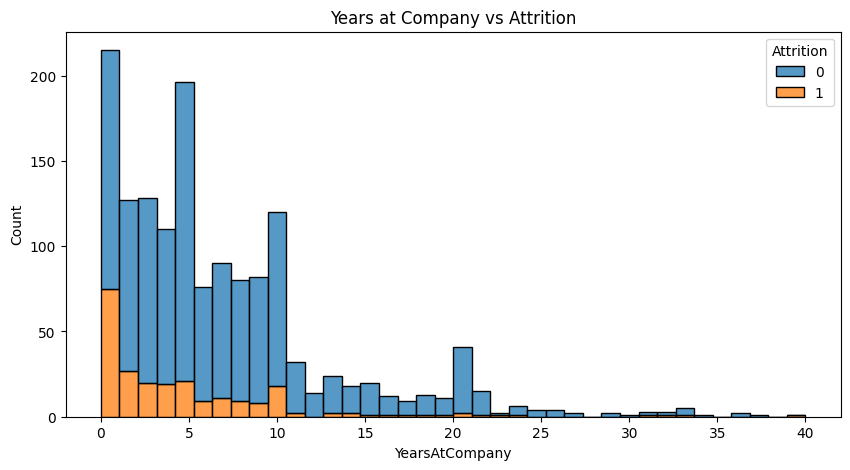

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=eda_df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack"
)

plt.title("Years at Company vs Attrition")

plt.savefig("chart5_years_attrition.png", dpi=300, bbox_inches="tight")

plt.show()

In [40]:
department_attrition = (
    eda_df.groupby("Department")["Attrition"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(department_attrition)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


In [41]:
job_attrition = (
    eda_df.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(job_attrition)

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


## Task 3: Business Insights

1. The Sales department has the highest attrition rate (approximately 20.63%), followed closely by Human Resources (19.05%). Research & Development has the lowest attrition rate (13.84%).

2. Sales Representatives experience the highest attrition rate (39.76%), making them the most vulnerable job role. Laboratory Technicians (23.94%) and Human Resources employees (23.08%) also show relatively high attrition.

3. Employees who left the company generally have lower monthly incomes than employees who stayed, indicating that salary may influence attrition.

4. Employees with the lowest Work-Life Balance rating (rating = 1) have the highest attrition rate, suggesting that poor work-life balance is associated with increased employee turnover.

5. Most employees who leave the company tend to do so within the first 10 years, with attrition appearing more common during the early years of employment than among long-tenured employees.

In [42]:
# Logistic Regression
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

log_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [43]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [44]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_prob = gb_model.predict_proba(X_test)[:,1]

In [45]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC-AUC":[
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

comparison

,Model,ROC-AUC
0,Logistic Regression,0.798260
1,Random Forest,0.751486
2,Gradient Boosting,0.794125


In [46]:
print("Logistic Regression")

print(classification_report(y_test, log_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [47]:
print("Random Forest")

print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



In [48]:
print("Gradient Boosting")

print(classification_report(y_test, gb_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



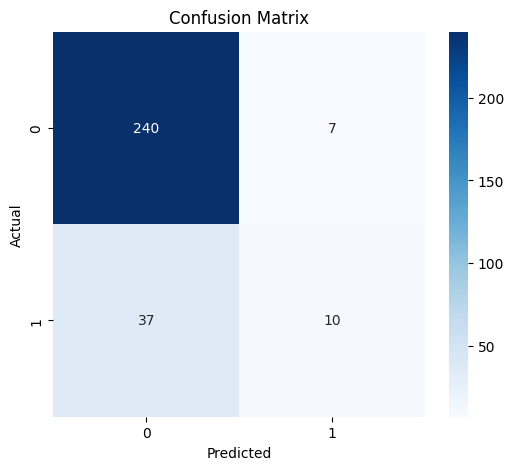

In [49]:
cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("chart6_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [50]:
importance = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10)

,0
MonthlyIncome,0.109081
Age,0.093560
OverTime_Yes,0.088694
TotalWorkingYears,0.084067
NumCompaniesWorked,0.050086
StockOptionLevel,0.047109
DailyRate,0.045122
YearsWithCurrManager,0.043466
EnvironmentSatisfaction,0.038851
JobInvolvement,0.038142


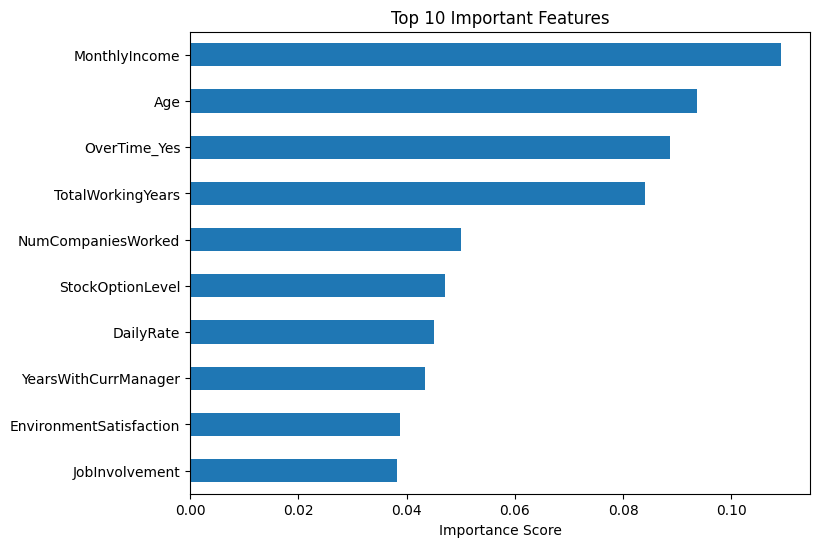

In [51]:
plt.figure(figsize=(8,6))

importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.savefig("chart7_feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

## HR Insights & Business Recommendations

### Key Factors Influencing Attrition

Based on the model and exploratory analysis, the strongest factors influencing employee attrition are:

- Monthly Income
- Age
- Overtime
- Total Working Years
- Number of Companies Worked
- Stock Option Level

### Departments Requiring Attention

The Sales department shows the highest attrition rate, while Sales Representatives experience the highest attrition among all job roles. HR should prioritize retention efforts for these employees.

### Does Salary Alone Explain Attrition?

No. Although employees with lower monthly income are more likely to leave, other factors such as overtime, age, work-life balance, and total working experience also contribute significantly.

### HR Recommendations

1. Conduct regular retention interviews with employees in Sales, especially Sales Representatives and Laboratory Technicians.

2. Improve work-life balance by reducing excessive overtime and providing flexible working arrangements where possible.

### Model Limitation

The model is trained using historical employee data and cannot account for future organizational changes or personal reasons for resignation. Therefore, predictions should support HR decision-making rather than replace human judgment.

## Model Comparison Conclusion

Three machine learning models were evaluated for predicting employee attrition.

Although Gradient Boosting achieved the highest overall accuracy (85%), Logistic Regression achieved the highest ROC-AUC score (0.798) and, more importantly, the highest recall (62%) for employees who actually left the company.

Since identifying employees who are likely to leave is the primary business objective, Logistic Regression was selected as the preferred model. Gradient Boosting was additionally used to analyze feature importance because it provides interpretable importance scores for the input features.

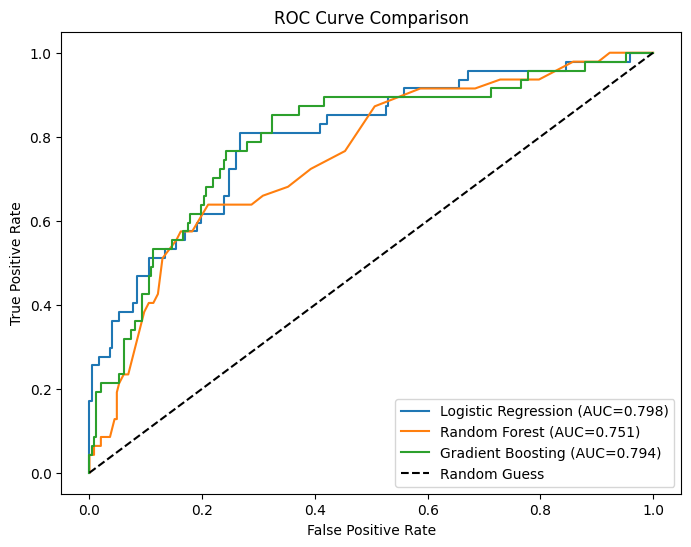

In [52]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={roc_auc_score(y_test, log_prob):.3f})")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})")

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={roc_auc_score(y_test, gb_prob):.3f})")

# Random Classifier
plt.plot([0,1], [0,1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("chart8_roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()